note:
Discussion point: 
Identify the limitations of BoW: high dimensionality, sparsity, loss of word order, and absence of semantic relationships.
Describe the distributional hypothesis ("a word is known by the company it keeps") and how it motivates word embeddings.
Explain why static embeddings cannot handle polysemy or context, motivating the move to contextual models.
Compare BoW, Word2Vec, and BERT representations on the same text and articulate the tradeoffs (interpretability, compute cost, semantic richness) that guide which to use for a given social-science analysis.

# Text Vectorization: from BoW to Word2Vec to BERT

* * * 

### This tutorial is adapted from
- https://github.com/dlab-berkeley/Python-NLP-Fundamentals


In the previous tutorial, we learned how to clean and preprocess text. But preprocessed text is still just text — and computers don't operate on words, they operate on numbers. Before we can do *any* computational analysis (clustering documents, classifying tweets, measuring similarity between speeches, training a model), we need a way to turn text into a **numeric representation**.

This tutorial walks through three landmark approaches to that problem, each one motivated by the limitations of the last:

1. **Bag-of-Words (BoW)** — the most straightforward representation: count which words appear in each document. Simple, interpretable, and still a strong baseline for many social-science tasks. 

2. **Word2Vec** — learns *dense* word vectors from the contexts in which words appear, so that semantically related words end up close together in vector space. 

3. **BERT** — produces *contextual* embeddings: the vector for "bank" in "river bank" differs from "bank" in "investment bank." This is the representation that powers most modern NLP.

By the end, you'll have hands-on experience with all three and a clearer sense of which one to reach for in your own analyses.

We'll lean on `scikit-learn` for BoW, `gensim` for Word2Vec, and `transformers` (Hugging Face) for BERT.

Let's install `scikit-learn` first!


In [ ]:
# Uncomment to install the package
# !pip install scikit-learn

In [3]:
# Import other packages
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation
%matplotlib inline

In [4]:
# Load data (for public sharing) 
import os
import gdown

# Upload the data file to your Google Drive, and turn on the link sharing
# Replace 'YOUR_FILE_ID' with the actual file ID from your public Google Drive link e.g., "https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing"
file_id = '1qqIG8_-Y4JwbBj86aR_1hnaIJOkOjgxS'

# Name for the downloaded file in Colab
output_filename = 'airline_tweets.csv'

if file_id and not os.path.exists(output_filename):
    gdown.download(id=file_id, output=output_filename, quiet=False)
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Using existing file '{output_filename}'.")

# Now you can load it with pandas
tweets= pd.read_csv(output_filename)
display(tweets.head())


Using existing file 'airline_tweets.csv'.


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


As a refresher, each row in this dataframe correponds to a tweet. The following columns are of main interests to us. There are other columns containing metadata of the tweet, such as the author of the tweet, when it was created, the timezone of the user, and others, which we will set aside for now. 

- `text` (`str`): the text of the tweet.
- `airline_sentiment` (`str`): the sentiment of the tweet, labeled as "neutral," "positive," or "negative." 
- `airline` (`str`): the airline that is tweeted about.
- `retweet count` (`int`): how many times the tweet was retweeted.


# Apply a Text Cleaning Pipeline 
Write a function called `preprocess` that performs the following steps on a text input:

* Step 1: Lowercase the text input.
* Step 2: Replace the following patterns with placeholders. ithout this, each unique URL or @handle becomes its own one-off column in the DTM ("vocab explosion")
    * URLs &rarr; ` URL `
    * Digits &rarr; ` DIGIT `
    * Hashtags &rarr; ` HASHTAG `
    * Tweet handles &rarr; ` USER `
* Step 3: Remove extra blankspace.

In [5]:
import re

def preprocess(text):
    '''Create a preprocess pipeline that cleans the tweet data.'''

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Replace patterns with placeholders
    def placeholder(text):
        # Regex patterns for URLs, digits, hashtags, and users
        url_pattern = r'(http|ftp|https):\/\/([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:\/~+#-]*[\w@?^=%&\/~+#-])'
        digit_pattern = r'\d+'
        hashtag_pattern = r'(?:^|\s)[＃#]{1}(\w+)'
        user_pattern = r'@(\w+)'

        # Replace URLs
        url_pattern = r'(http|ftp|https):\/\/([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:\/~+#-]*[\w@?^=%&\/~+#-])'
        url_repl = ' URL '
        text = re.sub(url_pattern, url_repl, text)
        # Replace digits
        digit_pattern = r'\d+'
        digit_repl = ' DIGIT '
        text = re.sub(digit_pattern, digit_repl, text)
        # Replace hashtags
        hashtag_pattern = r'(?:^|\s)[＃#]{1}(\w+)'
        hashtag_repl = ' HASHTAG '
        text = re.sub(hashtag_pattern, hashtag_repl, text)
        # Replace users
        user_pattern = r'@(\w+)'
        user_repl = ' USER '
        text = re.sub(user_pattern, user_repl, text)
        return text

    text = placeholder(text)

    # Step 3: Remove extra whitespace characters
    blankspace_pattern = r'\s+'
    blankspace_repl = ' '
    text = re.sub(blankspace_pattern, blankspace_repl, text)
    text = text.strip()
    
    return text


In [6]:
# Test with example tweet first
example_tweet = 'lol @justinbeiber and @BillGates are like soo 2000 #yesterday #amiright saw it on https://twitter.com #yolo'

# Print the example tweet
print(example_tweet)
print(f"{'='*50}")

# Print the preprocessed tweet
print(preprocess(example_tweet))

lol @justinbeiber and @BillGates are like soo 2000 #yesterday #amiright saw it on https://twitter.com #yolo
lol USER and USER are like soo DIGIT HASHTAG HASHTAG saw it on URL HASHTAG


In [7]:
# Apply the function to the text column and assign the preprocessed tweets to a new column
tweets['text_processed'] = tweets['text'].apply(lambda x: preprocess(x))
tweets['text_processed'].head()

0                                 USER what USER said.
1    USER plus you've added commercials to the expe...
2    USER i didn't today... must mean i need to tak...
3    USER it's really aggressive to blast obnoxious...
4        USER and it's a really big bad thing about it
Name: text_processed, dtype: str

<a id='section3'></a>
# The Bag-of-Words Representation

The idea of bag-of-words (BoW), as the name suggests, is quite intuitive: we take a document and toss it in a bag. The action of "throwing" the document in a bag disregards the relative position between words, so what is "in the bag" is essentially "an unsorted set of words" [(Jurafsky & Martin, 2024)](https://web.stanford.edu/~jurafsky/slp3/ed3book.pdf). In return, we have a list of unique words and the frequency of each of them. 

For example, as shown in the following illustration, the word "coffee" appears twice. 

<img src='./images/bow-illustration-1.png' alt="BoW-Part2" width="600">


## Document Term Matrix

Now let's implement the idea of bag-of-words. Before we dive deeper, let's step back for a moment. In practice, text analysis often involves handling many documents; from now on, we use the term **document** to represent a piece of text on which we perform analysis. It could be a phrase, a sentence, a tweet, or any other text—as long as it can be represented by a string, the length dosen't really matter. 

Imagine we have four documents (i.e., the four phrases shown above), and we toss them all in the bag. Instead of a word-frequency list, we'd expect a **document-term matrix (DTM)** in return. In a DTM, the word list is the **vocabulary** (V) that holds all unique words occur across the documents. For each **document** (D), we count the number of occurence of each word in the vocabulary, and then plug the number into the matrix. In other words, the DTM we will construct is a $D \times V$ matrix, where each row corresponds to a document, and each column corresponds to a token (or "term").

The unique tokens in this set of documents, arranged in alphabetical order, form the columns. For each document, we mark the occurence of each word present in the document. The numerical representation for each document is a row in the matrix. For example, the first document, "the coffee roaster," has the numerical representation $[0, 1, 0, 0, 0, 1, 1, 0]$.

Note that the left index column now displays these documents as text, but typically we would just assign an index to each of them. 

$$
\begin{array}{c|cccccccccccc}
 & \text{americano} & \text{coffee} & \text{iced} & \text{light} & \text{roast} & \text{roaster} & \text{the} & \text{time} \\\hline
\text{the coffee roaster} &0 &1	&0	&0	&0	&1	&1	&0 \\ 
\text{light roast} &0 &0	&0	&1	&1	&0	&0	&0 \\
\text{iced americano} &1 &0	&1	&0	&0	&0	&0	&0 \\
\text{coffee time} &0 &1	&0	&0	&0	&0	&0	&1 \\
\end{array}
$$

To create a DTM, we will use `CountVectorizer` from the package `sklearn`. Look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) and see what options are available.  

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

# A toy example containing four documents
test = ['the coffee roaster',
        'light roast',
        'iced americano',
        'coffee time']

# Create a CountVectorizer object
vectorizer = CountVectorizer() # For now we can just leave it blank to use the default settings. 

# Fit and transform to create a DTM
test_count = vectorizer.fit_transform(test)

print(test_count)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (4, 8)>
  Coords	Values
  (0, 6)	1
  (0, 1)	1
  (0, 5)	1
  (1, 3)	1
  (1, 4)	1
  (2, 2)	1
  (2, 0)	1
  (3, 1)	1
  (3, 7)	1


Apparently we've got a "sparse matrix"—a matrix that contains a lot of zeros. This makes sense. For each document, there are words that don't occur at all, and these are counted as zero in the DTM. This sparse matrix is stored in a "Compressed Sparse Row" format, a memory-saving format designed for handling sparse matrices. 

Let's convert it to a dense matrix, where those zeros are probably represented, as in a numpy array.

In [ ]:
# Convert DTM to a dense matrix 
test_count.todense()

So this is our DTM! The matrix is the same as shown above. To make it more reader-friendly, let's convert it to a dataframe. The column names should be tokens in the vocabulary, which we can access with the `get_feature_names_out` function.

In [ ]:
# Create a DTM dataframe
print("column names: ", vectorizer.get_feature_names_out())
test_dtm = pd.DataFrame(data=test_count.todense(),
                        columns=vectorizer.get_feature_names_out())
display(test_dtm)


## DTM for Tweets

We'll begin by initializing a `CountVectorizer` object. In the following cell, we have included a few parameters that people often adjust. These parameters are currently set to their default values.

When we construct a DTM, the default is to lowercase the input text. If nothing is provided for `stop_words`, the default is to keep them. The next three parameters are used to control the size of the vocabulary, which we'll return to in a minute.

In [18]:
# Create a CountVectorizer object
vectorizer = CountVectorizer(lowercase=True,
                             stop_words=None,
                             min_df=1,
                             max_df=1.0, 
                             max_features=None)
# Fit and transform to create DTM
counts = vectorizer.fit_transform(tweets['text_processed'])
counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 230849 stored elements and shape (14640, 9913)>

In [19]:
# Extract tokens
tokens = vectorizer.get_feature_names_out()
# Create DTM
first_dtm = pd.DataFrame(data=counts.todense(),
                         index=tweets.index,
                         columns=tokens)
print("DTM shape: ", first_dtm.shape)
first_dtm.head()



DTM shape:  (14640, 9913)


,_exact_,_wtvd,aa,aaaand,aadavantage,aadv,aadvantage,aal,aaron,ab,...,zero,zig,zip,zippers,zone,zones,zoom,zukes,zurich,zz
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Most frequent tokens
first_dtm.sum().sort_values(ascending=False).head(10) # default axis=0 (over rows)

In [ ]:
# Which token appears most frequently in each tweet?
counts = pd.DataFrame()
counts['token'] = first_dtm.idxmax(axis=1) # axis=1 (over columns)

# Retrieve the number of occurrence 
counts['number'] = first_dtm.max(axis=1)
counts


# Filter out placeholders
counts[(counts['token']!='digit')
       & (counts['token']!='hashtag')
       & (counts['token']!='user')].sort_values('number', ascending=False).head(10)

It looks like among all tweets, at most a token appears six times, and it is either the word "It" or the word "worst." 

Let's go back to our tweets dataframe and locate the 918th tweet.

In [ ]:
# Retrieve 1214th tweet: "worst"
tweets.iloc[1214]['text']

## Customize the `CountVectorizer`

So far we've always used the default parameter setting to create our DTMs, but in many cases we may want to customize the `CountVectorizer` object. The purpose of doing so is to further filter out unnecessary tokens. In the example below, we tweak the following parameters:

- `stop_words = 'english'`: ignore English stop words 
- `min_df = 2`: ignore words that don't occur at least twice
- `max_df = 0.95`: ignore words if they appear in more than 95\% of the documents

Oftentimes, we are not interested in words whose frequencies are either too low or too high, so we use `min_df` and `max_df` to filter them out. Alternatively, we can define our vocabulary size as $N$ by setting `max_features`. In other words, we tell `CountVectorizer` to only consider the top $N$ most frequent tokens when constructing the DTM.

In [21]:
# Customize the parameter setting
vectorizer = CountVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)
# Fit, transform, and get tokens
counts = vectorizer.fit_transform(tweets['text_processed'])
tokens = vectorizer.get_feature_names_out()

# Create the second DTM
second_dtm = pd.DataFrame(data=counts.todense(),
                          index=tweets.index,
                          columns=tokens)

print(first_dtm.shape)
print(second_dtm.shape)

(14640, 9913)
(14640, 5152)


Our second DTM has a substantially smaller vocabulary compared to the first one.

In [ ]:
second_dtm.sum().sort_values(ascending=False).head(10)

## Lemmatize the Text Input

So far, our DTM treats **every word form as a separate token**. That means "run", "runs", "running", and "ran" are all stored in different columns — even though, for most analyses, they refer to the same underlying concept.

This is wasteful in two ways:
1. It inflates the vocabulary (more columns, more sparsity).
2. It splits the signal: a topic about "running" gets diluted across four near-synonymous features instead of being concentrated in one.

The standard fix is to collapse word variants into a single canonical form. There are two common approaches:

### Stemming
Chops off suffixes using simple rules. Fast, but crude — it doesn't care whether the result is a real word.

```
running  → run
runs     → run
ran      → ran      ← stemmer can't handle irregular forms
studies  → studi    ← result isn't a real word
better   → better   ← can't relate to "good"
```


### Lemmatization
Looks up the dictionary base form (the "lemma") of each word, using part-of-speech information. Slower, but linguistically correct.

```
running  → run
ran      → run
studies  → study
better   → good
```

This requires a model that knows the language's morphology and vocabulary — which is exactly what `spaCy` provides.

Now let's implement lemmatization on our tweet data and use the lemmatized text to create a third DTM.



In [8]:
# Import spaCy
import spacy
nlp = spacy.load('en_core_web_sm')

# Create a function to lemmatize text
def lemmatize_text(text):
    '''Lemmatize the text input with spaCy annotations.'''

    # Step 1: Initialize an empty list to hold lemmas
    lemma = []

    # Step 2: Apply the nlp pipeline to input text
    doc = nlp(text)

    # Step 3: Iterate over tokens in the text to get the token lemma
    for token in doc:
        lemma.append(token.lemma_)

    # Step 4: Join lemmas together into a single string
    text_lemma = ' '.join(lemma)
    
    return text_lemma

In [9]:
# Apply the function to an example tweet
print(tweets.iloc[101]["text_processed"])
print(f"{'='*50}")
print(lemmatize_text(tweets.iloc[101]['text_processed']))

USER why must a traveler miss a flight to late flight check a bag? i missed my morning appointments and you lost my business. HASHTAG DIGIT lax
USER why must a traveler miss a flight to late flight check a bag ? I miss my morning appointment and you lose my business . HASHTAG DIGIT lax


In [10]:
# This may take a while!
tweets['text_lemmatized'] = tweets['text_processed'].apply(lambda x: lemmatize_text(x))

In [12]:
# Print the preprocessed tweet
print(tweets['text_processed'].iloc[101])
print(f"{'='*50}")
# Print the lemmatized tweet
print(tweets['text_lemmatized'].iloc[101])

USER why must a traveler miss a flight to late flight check a bag? i missed my morning appointments and you lost my business. HASHTAG DIGIT lax
USER why must a traveler miss a flight to late flight check a bag ? I miss my morning appointment and you lose my business . HASHTAG DIGIT lax


Now with the `text_lemmatized` column, let's create a third DTM. The parameter setting is the same as the second DTM. 

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
# Create the vectorizer (the same param setting as previous)
vectorizer = CountVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

# Fit, transform, and get tokens
counts = vectorizer.fit_transform(tweets['text_lemmatized'])
tokens = vectorizer.get_feature_names_out()

# Create the third DTM
third_dtm = pd.DataFrame(data=counts.todense(),
                         index=tweets.index,
                         columns=tokens)

# Print the shapes of three DTMs
print(first_dtm.shape)
print(second_dtm.shape)
print(third_dtm.shape)

third_dtm.head()

(14640, 9913)
(14640, 5152)
(14640, 4115)


,aa,aadv,aadvantage,aal,abandon,abc,abi,ability,able,aboard,...,yup,yvonne,yvr,yyj,yyz,zero,zone,zoom,zurich,zz
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Let's print the top 10 most frequent tokens as usual. These tokens are now lemmas and their counts also change after lemmatization. 

In [23]:
# Get the most frequent tokens in the third DTM
third_dtm.sum().sort_values(ascending=False).head(10)

digit      8427
flight     4749
hashtag    3243
thank      1673
url        1211
hour       1166
cancel     1049
service    1002
delay       983
just        974
dtype: int64

In [24]:
# Get the most frequent tokens in the third DTM
second_dtm.sum().sort_values(ascending=False).head(10)

digit        8427
flight       3935
hashtag      3243
url          1211
thanks       1078
cancelled    1057
just          974
service       965
help          855
time          793
dtype: int64

<a id='section4'></a>

# Term Frequency-Inverse Document Frequency (TF-IDF)

So far, we're relying on word frequency to give us information about a document. This assumes if a word appears more often in a document, it's more informative. However, this may not always be the case. For example, we've already removed stop words because they are not informative, despite the fact that they appear many times in a document. We also know the word "flight" is among the most frequent words, but it is not that informative, because it appears in many documents. Since we're looking at airline tweets, we shouldn't be surprised to see the word "flight"!

To remedy this, we use a weighting scheme called **tf-idf (term frequency-inverse document frequency)**. The big idea behind tf-idf is to weight a word not just by its frequency within a document, but also by its frequency in one document relative to the remaining documents. So, when we construct the DTM, we will be assigning each term a **tf-idf score**. Specifically, term $t$ in document $d$ is assigned a tf-idf score as follows:

<img src='./images/tf-idf_finalized.png' alt="TF-IDF" width="1200">

In essence, the tf-idf score of a word in a document is the product of two components: **term frequency (tf)** and **inverse document frequency (idf)**. The idf acts as a scaling factor. If a word occurs in all documents, then idf equals 1. No scaling will happen. But idf is typically greater than 1, which is the weight we assign to the word to make the tf-idf score higher, so as to highlight that the word is informative. In practice, we add 1 to both the denominator and numerator ("add-1 smooth") to prevent any issues with zero occurrences.

We can also create a tf-idf DTM using `sklearn`. We'll use a `TfidfVectorizer` this time:

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a tfidf vectorizer
vectorizer = TfidfVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

# Fit and transform 
tf_dtm = vectorizer.fit_transform(tweets['text_lemmatized'])

# Create a tf-idf dataframe
tfidf = pd.DataFrame(tf_dtm.todense(),
                     columns=vectorizer.get_feature_names_out(),
                     index=tweets.index)
tfidf.head()

,aa,aadv,aadvantage,aal,abandon,abc,abi,ability,able,aboard,...,yup,yvonne,yvr,yyj,yyz,zero,zone,zoom,zurich,zz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Interpret TF-IDF Values

Using the TF-IDF table, you can identify the most important token(s) for each document (a tweet in our case).

In [39]:
# Get the most important tokens in the 1214th tweet
print(tweets.iloc[1214]['text_lemmatized'])
tfidf.iloc[1214].sort_values(ascending=False).head(10)

USER be the bad . bad reservation policy . bad costumer service . worst worst bad . congrat , USER you be not that bad !


bad            0.711821
worst          0.539096
costumer       0.256709
congrat        0.243869
policy         0.191866
reservation    0.163469
service        0.117390
plough         0.000000
plot           0.000000
plitt          0.000000
Name: 1214, dtype: float64

You can also look at which tokens are distinctive for a *group* of tweets — e.g., those with positive vs. negative valence.

To explore this, we'll gather the indices of all positive (and negative) tweets and compute the mean TF-IDF score of each token within each group. Tokens with a high mean score in one group but not the other are the ones characterizing that sentiment.


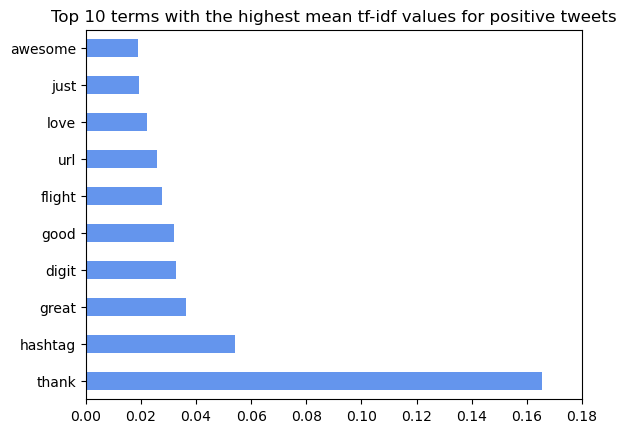

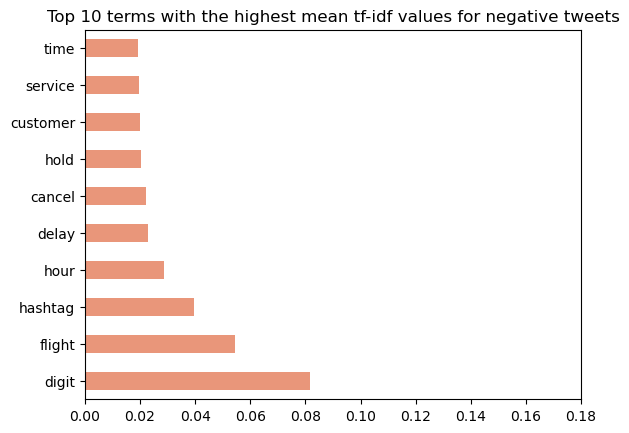

In [45]:
# Complete the boolean masks 
positive_index = tweets[tweets['airline_sentiment'] == 'positive'].index
negative_index = tweets[tweets['airline_sentiment'] == 'negative'].index

# Complete the following two lines
pos = tfidf.loc[positive_index].mean().sort_values(ascending=False).head(10) # axis=0, mean over documents
neg = tfidf.loc[negative_index].mean().sort_values(ascending=False).head(10)

# plot the top 10 terms with the highest mean tf-idf values for positive/negative tweets
pos.plot(kind='barh', 
         xlim=(0, 0.18),
         color='cornflowerblue',
         title='Top 10 terms with the highest mean tf-idf values for positive tweets')
plt.show()

neg.plot(kind='barh', 
         xlim=(0, 0.18),
         color='darksalmon',
         title='Top 10 terms with the highest mean tf-idf values for negative tweets')
plt.show()